In [109]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import xgboost as xgb


### Data Prep

In [110]:
panel = pl.read_parquet("data/microcap.parquet")

# Lag microstructure features
panel = panel.sort(["permno", "month"]).with_columns([
    pl.col("bidask").shift(1).over("permno").alias("bidask_lag"),
    pl.col("vol").shift(1).over("permno").alias("vol_lag"),
])

ALL_INSTRUMENTS = [
    "size", "momentum", "bm", "roa", "leverage",
    "bidask_lag", "vol_lag", "total_assets", "book_equity",
    "net_income", "gross_profit",
]

### Data Cleaning

In [111]:
def sanitize_data(df, chars, target="excess_ret"):
    df = df.filter(
        pl.col(target).is_not_null() & pl.col(target).is_finite()
    )
    
    # Do NOT fill missing characteristics → keep NaNs
    for c in chars:
        df = df.with_columns(pl.col(c).cast(pl.Float64))
    
    return df

In [112]:
def rank_standardize(df, chars):
    """Rank-standardize characteristics per month to [-0.5, 0.5]."""
    exprs = [
        (((pl.col(c).rank() / (pl.col(c).count().over("month") + 1)) - 0.5)).alias(c)
        for c in chars
    ]
    return df.with_columns(exprs)

### Tensor Construction 

In [113]:
def prepare_tensors(df, chars, target="excess_ret"):
    months = sorted(df["month"].unique())
    permnos = sorted(df["permno"].unique())

    N, T, L = len(permnos), len(months), len(chars)

    R = np.full((N, T), np.nan)
    Z = np.full((N, T, L), np.nan)

    perm_map = {p:i for i,p in enumerate(permnos)}
    month_map = {m:i for i,m in enumerate(months)}

    for row in df.iter_rows(named=True):
        i = perm_map[row["permno"]]
        t = month_map[row["month"]]

        R[i, t] = row[target]
        for j, c in enumerate(chars):
            Z[i, t, j] = row[c]

    mask = (~np.isnan(R)) & (~np.isnan(Z).any(axis=2))

    return R, Z, mask, months

### Train/Test 

In [114]:
def time_split(df, train=0.6, val=0.2):
    months = sorted(df["month"].unique())
    T = len(months)

    t1 = int(train*T)
    t2 = int((train+val)*T)

    train_df = df.filter(pl.col("month") < months[t1])
    val_df   = df.filter((pl.col("month") >= months[t1]) & (pl.col("month") < months[t2]))
    test_df  = df.filter(pl.col("month") >= months[t2])

    return train_df, val_df, test_df

### IPCA -> ALS & Huber 

In [115]:
class IPCA:
    def __init__(self, K=5, reg=0.1, max_iter=50): # Increased reg for stability
        self.K = K
        self.reg = reg
        self.max_iter = max_iter

    def fit(self, R, Z, mask):
        N, T, L = Z.shape
        gamma = np.random.normal(0, 0.01, (L, self.K))
        F = np.zeros((self.K, T))

        for _ in range(self.max_iter):
            gamma_old = gamma.copy()
            # Factor step
            for t in range(T):
                idx = mask[:, t]
                if idx.sum() < self.K: continue
                Xt = Z[idx, t, :] @ gamma
                F[:, t] = np.linalg.solve(Xt.T @ Xt + self.reg * np.eye(self.K), Xt.T @ R[idx, t])

            # Gamma step
            A, b = np.zeros((L*self.K, L*self.K)), np.zeros(L*self.K)
            for t in range(T):
                idx = mask[:, t]
                if idx.sum() < self.K: continue
                Xt_kron = np.kron(F[:, t], Z[idx, t, :])
                A += Xt_kron.T @ Xt_kron
                b += Xt_kron.T @ R[idx, t]

            gamma = np.linalg.solve(A + self.reg * np.eye(L*self.K), b).reshape(L, self.K)
            gamma, _ = np.linalg.qr(gamma) # Identification constraint

            if np.linalg.norm(gamma - gamma_old) < 1e-5: break

        self.gamma, self.F = gamma, F
        self.F_mean = np.mean(F, axis=1)
        return self

### IPCA -> Portfolio

In [116]:
def managed_portfolio(R, Z, mask, K=5):
    N, T, L = Z.shape

    X = np.zeros((L, T))

    for t in range(T):
        idx = mask[:, t]
        if idx.sum() == 0:
            continue

        Zt = Z[idx, t, :]
        Rt = R[idx, t]

        # GLS-style weighting (variance stabilizing)
        w = 1 / (np.var(Rt) + 1e-6)

        X[:, t] = w * (Zt.T @ Rt) / idx.sum()

    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    gamma = U[:, :K]
    F = np.diag(S[:K]) @ Vt[:K, :]

    return gamma, F, np.mean(F, axis=1)

### XGBoost

In [117]:
def train_xgb(train_df, val_df, chars):
    X_train = train_df[chars].to_numpy()
    y_train = train_df["excess_ret"].to_numpy()

    X_val = val_df[chars].to_numpy()
    y_val = val_df["excess_ret"].to_numpy()

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=10
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    return model

### Autoencoder 

In [118]:
class BetaNet(nn.Module):
    def __init__(self, L, K):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(L, 64), nn.ReLU(), nn.Linear(64, K))
    def forward(self, z): return self.net(z)

def train_ae(df, chars, K=5, epochs=10):
    model = BetaNet(len(chars), K)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    months = sorted(df["month"].unique())
    
    final_factors = []
    for epoch in range(epochs):
        epoch_factors = []
        for m in months:
            batch = df.filter(pl.col("month") == m).drop_nulls(subset=chars + ["excess_ret"])
            if len(batch) < K: continue
            
            z = torch.tensor(batch[chars].to_numpy(), dtype=torch.float32)
            r = torch.tensor(batch["excess_ret"].to_numpy(), dtype=torch.float32).unsqueeze(1)
            
            beta = model(z)
            # Solve for f_t: (beta'beta)^-1 beta'r
            f_t = torch.linalg.lstsq(beta, r).solution
            epoch_factors.append(f_t.detach().numpy().flatten())
            
            loss = nn.MSELoss()(beta @ f_t, r)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        final_factors = epoch_factors

    f_mean = np.mean(final_factors, axis=0) if final_factors else np.zeros(K)
    return (model, f_mean)

### Metrics

In [ ]:
def oos_r2(model_type, model_obj, R, Z, mask, mode="predictive", chars=None, df=None):
    actual, pred = [], []

    if model_type == "xgb":
        y = df["excess_ret"].to_numpy()
        y_hat = model_obj.predict(df[chars].to_numpy())
        return 1 - np.mean((y - y_hat)**2) / np.mean(y**2)

    for t in range(R.shape[1]):
        idx = mask[:, t]
        if idx.sum() == 0: continue
        
        Zt, Rt = Z[idx, t, :], R[idx, t]

        if model_type == "ipca":
            beta = Zt @ model_obj.gamma
            f = model_obj.F[:, t] if mode == "total" else model_obj.F_mean

        elif model_type == "mp":
            # Correctly unpack the 3-element tuple from managed_portfolio()
            gamma, F_all, F_mean = model_obj
            beta = Zt @ gamma
            f = F_all[:, t] if mode == "total" else F_mean

        elif model_type == "ae":
            # Correctly unpack the 2-element tuple from train_ae()
            ae_net, f_mean = model_obj
            z_tensor = torch.tensor(Zt, dtype=torch.float32)
            beta = ae_net(z_tensor).detach().numpy()
            if mode == "total":
                f = np.linalg.lstsq(beta, Rt, rcond=None)[0]
            else:
                f = f_mean

        actual.extend(Rt)
        pred.extend(beta @ f)

    actual, pred = np.array(actual), np.array(pred)
    return 1 - np.mean((actual - pred)**2) / np.mean(actual**2)

### Hyper-parameter tuning

In [ ]:
def tune_models(R_tr, Z_tr, M_tr, R_val, Z_val, M_val):
    results = []
    print("--- Starting Hyperparameter Tuning ---")
    
    for k in [3, 5, 8]: 
        for reg in [0.001, 0.01, 0.1]: 
            model = IPCA(K=k, reg=reg).fit(R_tr, Z_tr, M_tr)
            
            # Evaluate on Validation set
            v_r2 = oos_r2("ipca", model, R_val, Z_val, M_val, mode="predictive")
            
            results.append({'K': k, 'reg': reg, 'val_r2': v_r2})
            print(f"Tested IPCA (K={k}, reg={reg}) -> Val R2: {v_r2:.4%}")
            
    best = max(results, key=lambda x: x['val_r2'])
    print(f"\nWINNER: K={best['K']}, reg={best['reg']} with {best['val_r2']:.4%}")
    return best

# Sanity Check

In [ ]:
def run_sanity_check(model_type, model_obj, test_df, chars):
    """
    Shuffles the characteristics in the test set. 
    If the R2 remains positive/high, your model is likely overfit or has a leak.
    """
    shuffled_df = test_df.clone()
    for c in chars:
        shuffled_df = shuffled_df.with_columns(pl.col(c).shuffle())
    
    R_shuff, Z_shuff, M_shuff, _ = prepare_tensors(shuffled_df, chars)
    
    bad_r2 = oos_r2(model_type, model_obj, R_shuff, Z_shuff, M_shuff)
    
    print(f"SANITY CHECK [{model_type.upper()}]:")
    print(f" -> Shuffled (Noise) R²: {bad_r2:.4%}")
    if bad_r2 > 0.0001: # 0.01% threshold
        print(" -> WARNING: High noise R². Possible overfitting or data leakage.")
    else:
        print(" -> PASS: Model ignores noise.")

In [ ]:
# Data Prep 
CHARS = ALL_INSTRUMENTS
train_df, val_df, test_df = time_split(panel)

# Apply rank standardization
train_df = rank_standardize(train_df, CHARS)
val_df   = rank_standardize(val_df, CHARS)
test_df  = rank_standardize(test_df, CHARS)

R_tr, Z_tr, M_tr, _ = prepare_tensors(train_df, CHARS)
R_va, Z_va, M_va, _ = prepare_tensors(val_df, CHARS)
R_te, Z_te, M_te, _ = prepare_tensors(test_df, CHARS)

#Tuning
best_params = tune_models(R_tr, Z_tr, M_tr, R_va, Z_va, M_va)

#Final Training
ipca_final = IPCA(K=best_params['K'], reg=best_params['reg']).fit(R_tr, Z_tr, M_tr)

# AE training 
ae_final = train_ae(train_df, CHARS, K=best_params['K'])

print("\n--- FINAL RESULTS ---")
real_ipca_r2 = oos_r2("ipca", ipca_final, R_te, Z_te, M_te)
real_ae_r2   = oos_r2("ae", ae_final, R_te, Z_te, M_te)

print(f"IPCA OOS R²: {real_ipca_r2:.4%}")
print(f"AE   OOS R²: {real_ae_r2:.4%}")

print("\n--- SANITY CHECKS ---")
run_sanity_check("ipca", ipca_final, test_df, CHARS)
run_sanity_check("ae", ae_final, test_df, CHARS)

--- Starting Hyperparameter Tuning ---
Tested IPCA (K=3, reg=0.001) -> Val R2: -0.6885%
Tested IPCA (K=3, reg=0.01) -> Val R2: 0.0677%
Tested IPCA (K=3, reg=0.1) -> Val R2: -0.0428%
Tested IPCA (K=5, reg=0.001) -> Val R2: 0.2592%
Tested IPCA (K=5, reg=0.01) -> Val R2: -1.0547%
Tested IPCA (K=5, reg=0.1) -> Val R2: -1.5662%
Tested IPCA (K=8, reg=0.001) -> Val R2: -1.3738%
Tested IPCA (K=8, reg=0.01) -> Val R2: -4.8367%
Tested IPCA (K=8, reg=0.1) -> Val R2: -1.1600%

WINNER: K=5, reg=0.001 with 0.2592%

--- FINAL RESULTS ---
IPCA OOS R²: 0.0332%
AE   OOS R²: 0.1244%

--- SANITY CHECKS ---
SANITY CHECK [IPCA]:
 -> Shuffled (Noise) R²: 0.0022%
 -> PASS: Model ignores noise.
SANITY CHECK [AE]:
 -> Shuffled (Noise) R²: 0.0212%
 -> WARNING: High noise R². Possible overfitting or data leakage.


In [ ]:
def tune_xgb(train_df, val_df, chars):
    best_r2 = -np.inf
    best_params = {}
    
    params_grid = {
        'n_estimators': [100, 300],
        'max_depth': [2, 3], 
        'learning_rate': [0.01, 0.05],
        'reg_lambda': [1, 10]
    }
    
    print("--- Starting XGBoost Hyperparameter Tuning ---")
    for n_est in params_grid['n_estimators']:
        for depth in params_grid['max_depth']:
            for lr in params_grid['learning_rate']:
                for lam in params_grid['reg_lambda']:
                    model = xgb.XGBRegressor(
                        n_estimators=n_est,
                        max_depth=depth,
                        learning_rate=lr,
                        reg_lambda=lam,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42,
                        n_jobs=-1
                    )
                    
                    # Train on training data
                    model.fit(train_df[chars].to_numpy(), train_df["excess_ret"].to_numpy())
                    
                    # Evaluate on validation data
                    v_r2 = oos_r2("xgb", model, None, None, None, chars=chars, df=val_df)
                    
                    print(f"XGB (n={n_est}, d={depth}, lr={lr}, L2={lam}) -> Val R2: {v_r2:.4%}")
                    
                    if v_r2 > best_r2:
                        best_r2 = v_r2
                        best_params = {
                            'n_estimators': n_est,
                            'max_depth': depth,
                            'learning_rate': lr,
                            'reg_lambda': lam
                        }
    
    print(f"\nWINNER XGB: {best_params} with Val R2 {best_r2:.4%}")
    return best_params

def run_sanity_check_v2(model_type, model_obj, test_df, chars):
    shuffled_df = test_df.clone()
    for c in chars:
        shuffled_df = shuffled_df.with_columns(pl.col(c).shuffle())
    
    if model_type == "xgb":
        bad_r2 = oos_r2("xgb", model_obj, None, None, None, chars=chars, df=shuffled_df)
    else:
        R_shuff, Z_shuff, M_shuff, _ = prepare_tensors(shuffled_df, chars)
        bad_r2 = oos_r2(model_type, model_obj, R_shuff, Z_shuff, M_shuff)
    
    print(f"SANITY CHECK [{model_type.upper()}]:")
    print(f" -> Shuffled (Noise) R²: {bad_r2:.4%}")

#tune XGB hyperparameters
xgb_best_params = tune_xgb(train_df, val_df, CHARS)

# Train & Test
xgb_final = xgb.XGBRegressor(
    **xgb_best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_final.fit(train_df[CHARS].to_numpy(), train_df["excess_ret"].to_numpy())

print("\n--- FINAL XGB PERFORMANCE ---")
final_xgb_r2 = oos_r2("xgb", xgb_final, None, None, None, chars=CHARS, df=test_df)
print(f"XGB OOS R²: {final_xgb_r2:.4%}")

#Sanity Check
run_sanity_check_v2("xgb", xgb_final, test_df, CHARS)

--- Starting XGBoost Hyperparameter Tuning ---
XGB (n=100, d=2, lr=0.01, L2=1) -> Val R2: 0.5011%
XGB (n=100, d=2, lr=0.01, L2=10) -> Val R2: 0.5012%
XGB (n=100, d=2, lr=0.05, L2=1) -> Val R2: -0.1495%
XGB (n=100, d=2, lr=0.05, L2=10) -> Val R2: 0.2200%
XGB (n=100, d=3, lr=0.01, L2=1) -> Val R2: 0.3019%
XGB (n=100, d=3, lr=0.01, L2=10) -> Val R2: 0.3666%
XGB (n=100, d=3, lr=0.05, L2=1) -> Val R2: -0.7532%
XGB (n=100, d=3, lr=0.05, L2=10) -> Val R2: -0.4085%
XGB (n=300, d=2, lr=0.01, L2=1) -> Val R2: 0.2247%
XGB (n=300, d=2, lr=0.01, L2=10) -> Val R2: 0.3905%
XGB (n=300, d=2, lr=0.05, L2=1) -> Val R2: -2.3061%
XGB (n=300, d=2, lr=0.05, L2=10) -> Val R2: -1.2860%
XGB (n=300, d=3, lr=0.01, L2=1) -> Val R2: -0.3999%
XGB (n=300, d=3, lr=0.01, L2=10) -> Val R2: -0.0844%
XGB (n=300, d=3, lr=0.05, L2=1) -> Val R2: -3.9165%
XGB (n=300, d=3, lr=0.05, L2=10) -> Val R2: -2.1700%

WINNER XGB: {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01, 'reg_lambda': 10} with Val R2 0.5012%

--- FIN

In [ ]:
def calculate_market_adjusted_r2(df, preds, chars):
    """
    Calculates the Total OOS R2 and the Cross-Sectional (Market-Adjusted) R2.
    """
    temp_df = df.select(["month", "excess_ret"]).with_columns(
        pl.Series("pred", preds)
    )
    
    #Total OOS R2 
    actual = temp_df["excess_ret"].to_numpy()
    pred = temp_df["pred"].to_numpy()
    total_r2 = 1 - np.mean((actual - pred)**2) / np.mean(actual**2)
    
    # 2. Market-Adjusted (Cross-Sectional) R2
    xs_stats = temp_df.with_columns([
        (pl.col("excess_ret") - pl.col("excess_ret").mean().over("month")).alias("actual_dm"),
        (pl.col("pred") - pl.col("pred").mean().over("month")).alias("pred_dm")
    ])
    
    actual_dm = xs_stats["actual_dm"].to_numpy()
    pred_dm = xs_stats["pred_dm"].to_numpy()
    
    xs_r2 = 1 - np.mean((actual_dm - pred_dm)**2) / np.mean(actual_dm**2)
    
    return total_r2, xs_r2

# Evaluate XGB with Market-Adjusted R2
test_clean = test_df.drop_nulls(subset=CHARS + ["excess_ret"])
real_preds = xgb_final.predict(test_clean[CHARS].to_numpy())
total_r2, xs_r2 = calculate_market_adjusted_r2(test_clean, real_preds, CHARS)

#Shuffled Sanity Check
shuffled_test = test_clean.clone()
for c in CHARS:
    shuffled_test = shuffled_test.with_columns(pl.col(c).shuffle())
noise_preds = xgb_final.predict(shuffled_test[CHARS].to_numpy())
total_noise, xs_noise = calculate_market_adjusted_r2(shuffled_test, noise_preds, CHARS)

print(f"--- XGBOOST MARKET-ADJUSTED TEST ---")
print(f"Total OOS R²:      {total_r2:.4%} (Includes Market Timing)")
print(f"Cross-Sectional R²: {xs_r2:.4%} (Pure Stock Picking)")
print(f"\n--- SHUFFLED SANITY CHECK ---")
print(f"Total Noise R²:    {total_noise:.4%}")
print(f"XS Noise R²:       {xs_noise:.4%}")

--- XGBOOST MARKET-ADJUSTED TEST ---
Total OOS R²:      0.3258% (Includes Market Timing)
Cross-Sectional R²: 0.0177% (Pure Stock Picking)

--- SHUFFLED SANITY CHECK ---
Total Noise R²:    0.1458%
XS Noise R²:       -0.0159%


Top 5 Driving Characteristics for XGBoost:
 - momentum: 0.1833
 - bm: 0.1595
 - size: 0.1508
 - leverage: 0.1432
 - book_equity: 0.1285


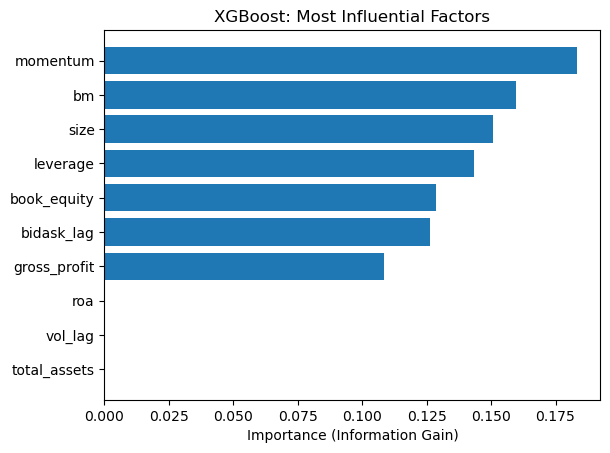

In [132]:
import matplotlib.pyplot as plt

# Extract feature importance from the trained XGB model
importances = xgb_final.feature_importances_
feat_importance = sorted(zip(CHARS, importances), key=lambda x: x[1], reverse=True)

print("Top 5 Driving Characteristics for XGBoost:")
for name, val in feat_importance[:5]:
    print(f" - {name}: {val:.4f}")

# Visualize
plt.barh([x[0] for x in feat_importance[:10]][::-1], [x[1] for x in feat_importance[:10]][::-1])
plt.title("XGBoost: Most Influential Factors")
plt.xlabel("Importance (Information Gain)")
plt.show()